--- DATASET INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB

--- STATISTICAL SUMMARY ---
       transaction_id        amount  transaction_hour  foreign_transaction  \
count     10000.00000  10000.000000      10000.000000         10000.000000   
mean       5000

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9900\4181964013.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amount', data=df, palette='Set2')


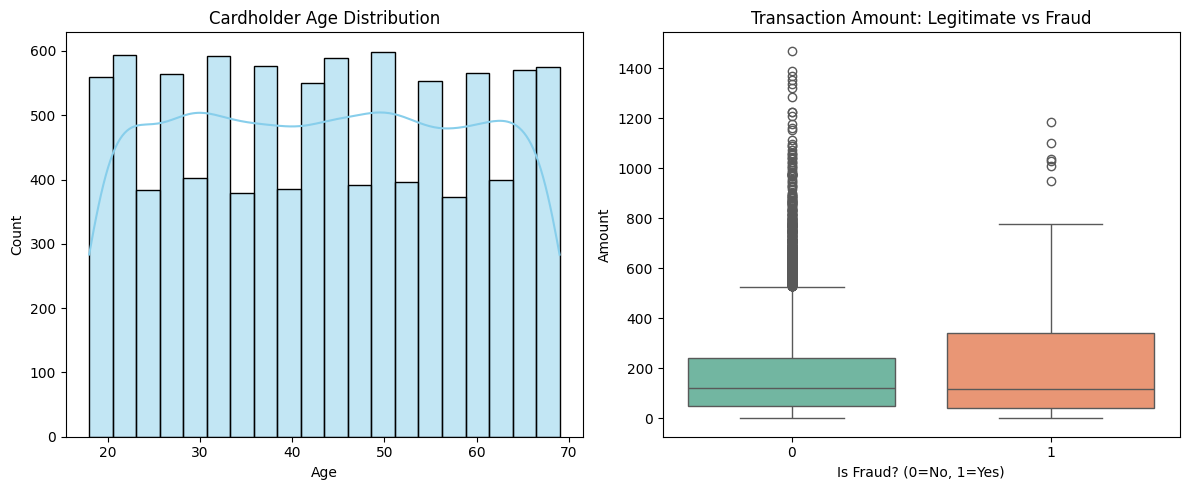

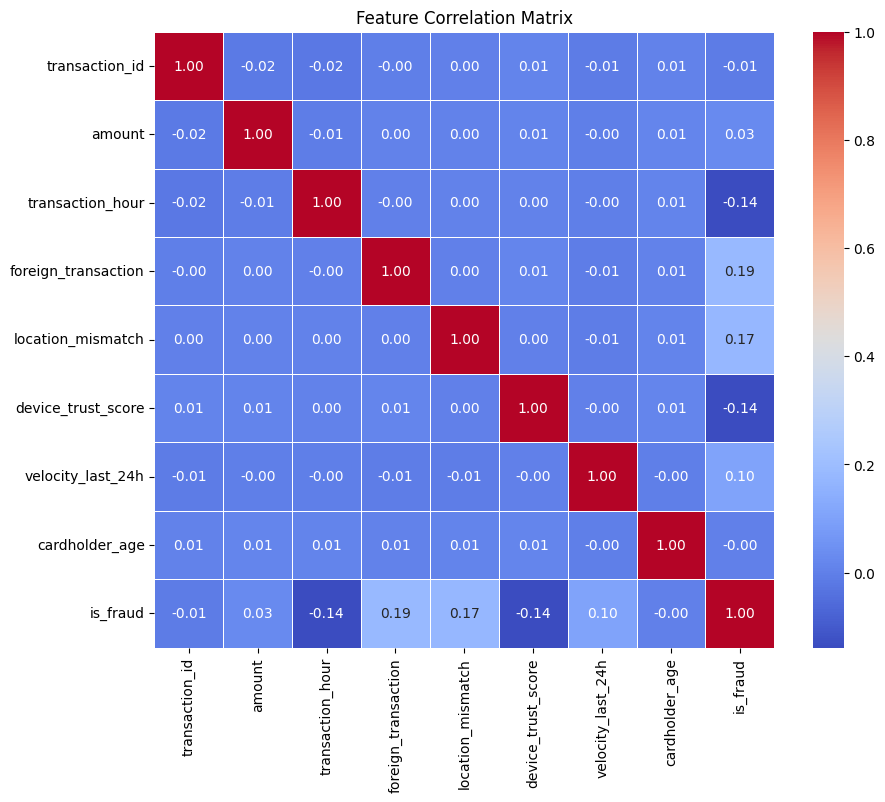

In [4]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv('credit_card_fraud_10k.csv')

# --- HINT A: Using .info(), .describe(), and .value_counts() ---
print("--- DATASET INFORMATION ---")
df.info()

print("\n--- STATISTICAL SUMMARY ---")
print(df.describe())

print("\n--- FRAUD CASE DISTRIBUTION (0=Legitimate, 1=Fraud) ---")
print(df['is_fraud'].value_counts())


# --- HINT D: Plot Histograms & Boxplots ---
plt.figure(figsize=(12, 5))

# Histogram: Distribution of Cardholder Age
plt.subplot(1, 2, 1)
sns.histplot(df['cardholder_age'], bins=20, kde=True, color='skyblue')
plt.title('Cardholder Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

# Boxplot: Spotting Outliers in Transaction Amount
plt.subplot(1, 2, 2)
sns.boxplot(x='is_fraud', y='amount', data=df, palette='Set2')
plt.title('Transaction Amount: Legitimate vs Fraud')
plt.xlabel('Is Fraud? (0=No, 1=Yes)')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()


# --- HINTS B & C: Heatmap for Correlation Analysis ---
plt.figure(figsize=(10, 8))
# Selecting only numerical columns for correlation matrix
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

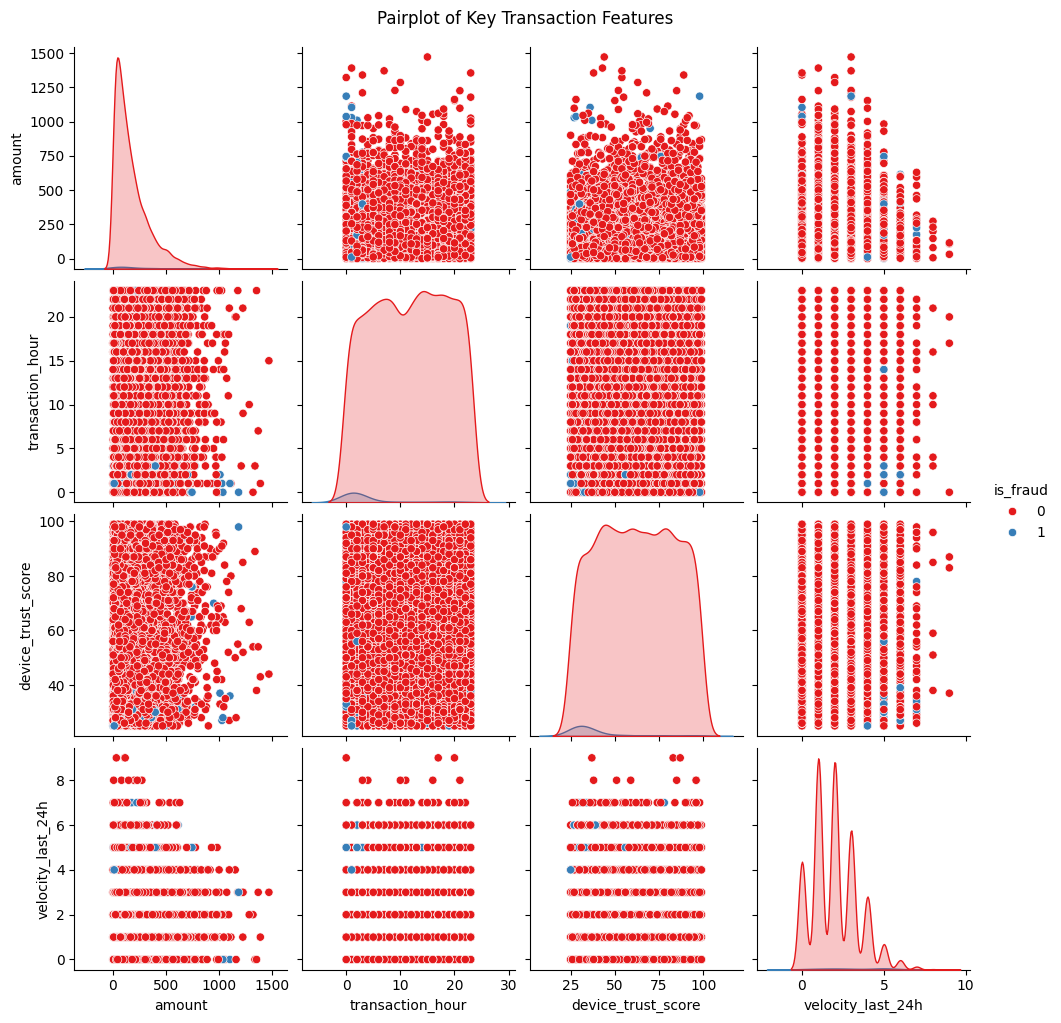

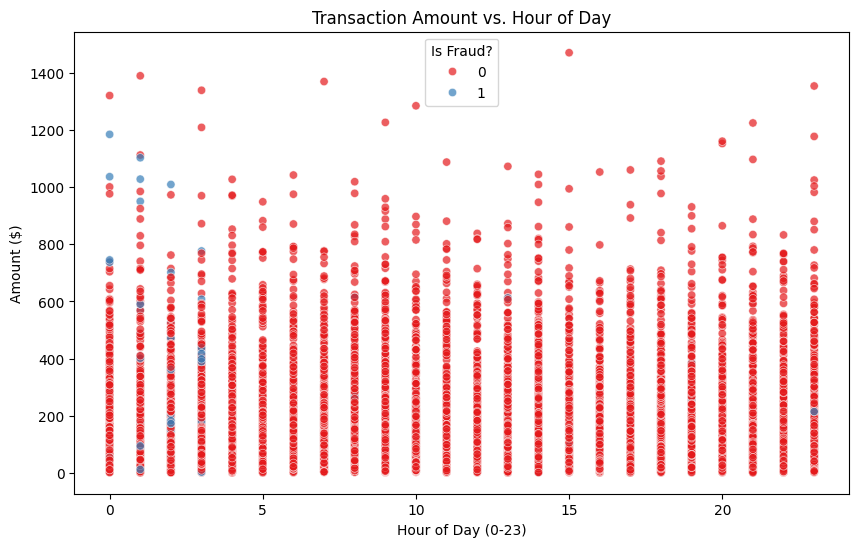

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9900\1167085988.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='merchant_category', y='is_fraud', data=df, errorbar=None, palette='viridis')


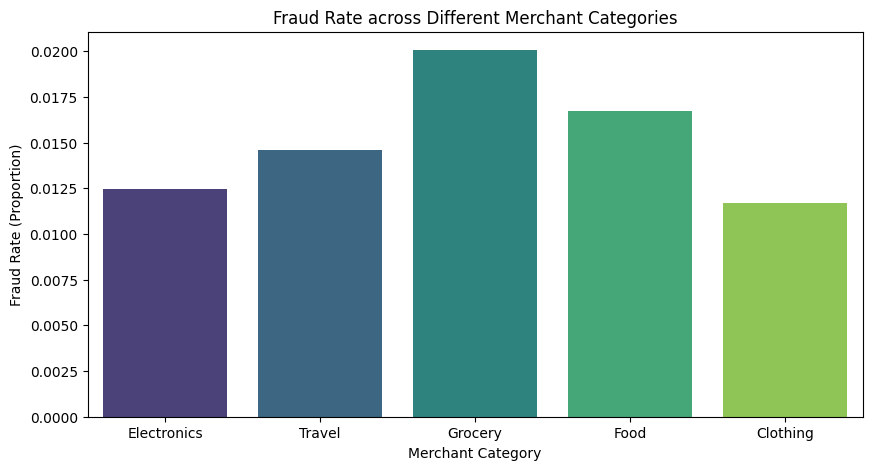

In [5]:
# --- HINT B & D: Advanced Visualizations (Pairplot & Scatterplot) ---

# 1. Pairplot (Sampling 1,000 rows to prevent lag, focusing on key metrics)
key_features = ['amount', 'transaction_hour', 'device_trust_score', 'velocity_last_24h', 'is_fraud']
sns.pairplot(df[key_features], hue='is_fraud', palette='Set1', diag_kind='kde')
plt.suptitle('Pairplot of Key Transaction Features', y=1.02)
plt.show()

# 2. Scatter Plot: Transaction Hour vs. Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='transaction_hour', y='amount', hue='is_fraud', data=df, palette='Set1', alpha=0.7)
plt.title('Transaction Amount vs. Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Amount ($)')
plt.legend(title='Is Fraud?')
plt.show()

# 3. Bar Plot: Fraud Rate by Merchant Category
plt.figure(figsize=(10, 5))
sns.barplot(x='merchant_category', y='is_fraud', data=df, errorbar=None, palette='viridis')
plt.title('Fraud Rate across Different Merchant Categories')
plt.xlabel('Merchant Category')
plt.ylabel('Fraud Rate (Proportion)')
plt.show()